# DS Lab 4: Linear Regression
Boston Housing Dataset

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.datasets import fetch_openml

In [24]:
# Load Boston Housing Dataset
boston = fetch_openml(name='boston', version=1, as_frame=True)
df = boston.frame
df.head()

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296.0,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242.0,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242.0,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222.0,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222.0,18.7,396.90,5.33,36.2


In [25]:
# Basic info
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 506 entries, 0 to 505
Data columns (total 14 columns):
 #   Column   Non-Null Count  Dtype   
---  ------   --------------  -----   
 0   CRIM     506 non-null    float64 
 1   ZN       506 non-null    float64 
 2   INDUS    506 non-null    float64 
 3   CHAS     506 non-null    category
 4   NOX      506 non-null    float64 
 5   RM       506 non-null    float64 
 6   AGE      506 non-null    float64 
 7   DIS      506 non-null    float64 
 8   RAD      506 non-null    category
 9   TAX      506 non-null    float64 
 10  PTRATIO  506 non-null    float64 
 11  B        506 non-null    float64 
 12  LSTAT    506 non-null    float64 
 13  MEDV     506 non-null    float64 
dtypes: category(2), float64(12)
memory usage: 49.0 KB


In [26]:
# Convert all columns to numeric
df = df.apply(pd.to_numeric, errors='coerce')

In [27]:
df.describe()


,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
count,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000
mean,3.613524,11.363636,11.136779,0.069170,0.554695,6.284634,68.574901,3.795043,9.549407,408.237154,18.455534,356.674032,12.653063,22.532806
std,8.601545,23.322453,6.860353,0.253994,0.115878,0.702617,28.148861,2.105710,8.707259,168.537116,2.164946,91.294864,7.141062,9.197104
min,0.006320,0.000000,0.460000,0.000000,0.385000,3.561000,2.900000,1.129600,1.000000,187.000000,12.600000,0.320000,1.730000,5.000000
25%,0.082045,0.000000,5.190000,0.000000,0.449000,5.885500,45.025000,2.100175,4.000000,279.000000,17.400000,375.377500,6.950000,17.025000
50%,0.256510,0.000000,9.690000,0.000000,0.538000,6.208500,77.500000,3.207450,5.000000,330.000000,19.050000,391.440000,11.360000,21.200000
75%,3.677083,12.500000,18.100000,0.000000,0.624000,6.623500,94.075000,5.188425,24.000000,666.000000,20.200000,396.225000,16.955000,25.000000
max,88.976200,100.000000,27.740000,1.000000,0.871000,8.780000,100.000000,12.126500,24.000000,711.000000,22.000000,396.900000,37.970000,50.000000


In [28]:
# Features and Target
X = df.drop('MEDV', axis=1)
y = df['MEDV']

In [29]:
# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [30]:
# Train Linear Regression model
model = LinearRegression()
model.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [32]:
# Predictions
y_pred = model.predict(X_test)
y_pred

array([28.99672362, 36.02556534, 14.81694405, 25.03197915, 18.76987992,
       23.25442929, 17.66253818, 14.34119   , 23.01320703, 20.63245597,
       24.90850512, 18.63883645, -6.08842184, 21.75834668, 19.23922576,
       26.19319733, 20.64773313,  5.79472718, 40.50033966, 17.61289074,
       27.24909479, 30.06625441, 11.34179277, 24.16077616, 17.86058499,
       15.83609765, 22.78148106, 14.57704449, 22.43626052, 19.19631835,
       22.43383455, 25.21979081, 25.93909562, 17.70162434, 16.76911711,
       16.95125411, 31.23340153, 20.13246729, 23.76579011, 24.6322925 ,
       13.94204955, 32.25576301, 42.67251161, 17.32745046, 27.27618614,
       16.99310991, 14.07009109, 25.90341861, 20.29485982, 29.95339638,
       21.28860173, 34.34451856, 16.04739105, 26.22562412, 39.53939798,
       22.57950697, 18.84531367, 32.72531661, 25.0673037 , 12.88628956,
       22.68221908, 30.48287757, 31.52626806, 15.90148607, 20.22094826,
       16.71089812, 20.52384893, 25.96356264, 30.61607978, 11.59

In [9]:
# Evaluation Metrics
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("MSE:", mse)
print("RMSE:", rmse)
print("R2 Score:", r2)

MSE: 24.291119474973538
RMSE: 4.928602182665339
R2 Score: 0.6687594935356317


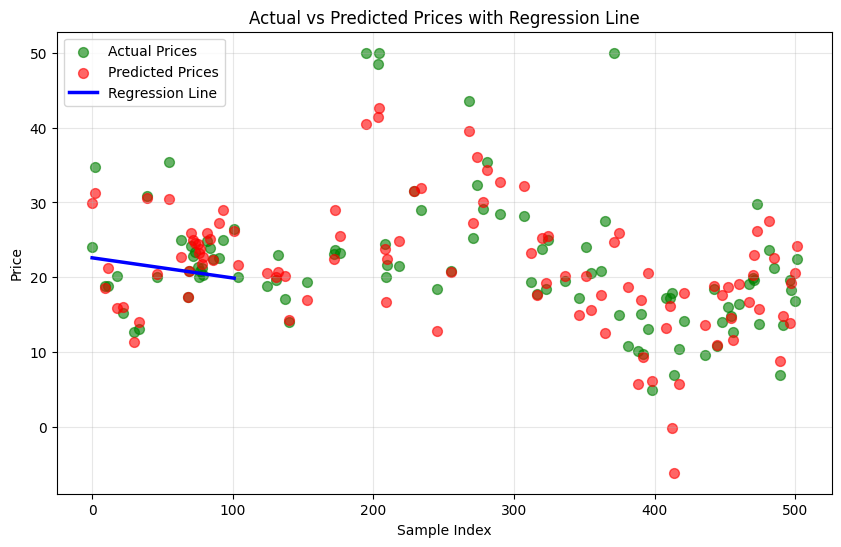

In [54]:
# Plot Actual vs Predicted with Regression Line
plt.figure(figsize=(10, 6))

# Scatter plot of actual prices (green)
plt.scatter(y_test.index, y_test, color='green', alpha=0.6, label='Actual Prices', s=50)

# Scatter plot of predicted prices (red)
plt.scatter(y_test.index, y_pred, color='red', alpha=0.6, label='Predicted Prices', s=50)

# Regression line through the predicted values (blue)
z = np.polyfit(range(len(y_test)), y_pred, 1)
p = np.poly1d(z)
plt.plot(range(len(y_test)), p(range(len(y_test))), color='blue', linewidth=2.5, label='Regression Line')

plt.xlabel("Sample Index")
plt.ylabel("Price")
plt.title("Actual vs Predicted Prices with Regression Line")
plt.legend(loc='upper left')
plt.grid(True, alpha=0.3)
plt.show()

In [ ]:
# Plot Actual vs Predicted Prices as Lines with Regression Line
plt.figure(figsize=(12, 6))

# Sort by actual prices for better line visualization
sorted_indices = np.argsort(y_test.values)
y_test_sorted = y_test.iloc[sorted_indices].reset_index(drop=True)
y_pred_sorted = y_pred[sorted_indices]

# Line plot for actual prices (green)
plt.plot(range(len(y_test_sorted)), y_test_sorted, color='green', linewidth=2, marker='o', markersize=4, label='Actual Prices', alpha=0.7)

# Line plot for predicted prices (red)
plt.plot(range(len(y_pred_sorted)), y_pred_sorted, color='red', linewidth=2, marker='s', markersize=4, label='Predicted Prices', alpha=0.7)

# Regression line through the predicted values (blue)
z = np.polyfit(range(len(y_pred_sorted)), y_pred_sorted, 1)
p = np.poly1d(z)
plt.plot(range(len(y_pred_sorted)), p(range(len(y_pred_sorted))), color='blue', linewidth=2.5, linestyle='--', label='Regression Line')

plt.xlabel("Sample Index (Sorted by Actual Price)")
plt.ylabel("Price")
plt.title("Input vs Output: Actual vs Predicted Prices with Regression Line")
plt.legend(loc='best')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [11]:
# Model coefficients
coeff_df = pd.DataFrame(model.coef_, X.columns, columns=['Coefficient'])
coeff_df

,Coefficient
CRIM,-0.113056
ZN,0.030110
INDUS,0.040381
CHAS,2.784438
NOX,-17.202633
RM,4.438835
AGE,-0.006296
DIS,-1.447865
RAD,0.262430
TAX,-0.010647


In [47]:
# Predict from test dataset by row number
row_num = int(input("Enter row number (0 to {}): ".format(len(X_test)-1)))
if 0 <= row_num < len(X):
    sample = X.iloc[row_num:row_num+1]
    prediction = model.predict(sample)[0]
    actual = y.iloc[row_num]
    print(f"\nRow {row_num}:")
    print(f"Actual Price: ${actual:.2f}")
    print(f"Predicted Price: ${prediction:.2f}")
    print(f"Difference: ${abs(actual - prediction):.2f}")
else:
    print("Invalid row number")


Row 4:
Actual Price: $36.20
Predicted Price: $28.55
Difference: $7.65


In [53]:
y.head(10)

0    24.0
1    21.6
2    34.7
3    33.4
4    36.2
5    28.7
6    22.9
7    27.1
8    16.5
9    18.9
Name: MEDV, dtype: float64